In [19]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Reading pickled objects

From /global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/notebooks/ChopTFs/pipeline/22_comparison_to_sanborn_intervals.ipynb

In [72]:
import pickle

mat = pd.read_pickle("../../data/ChopTFs_sanborn/mat.pkl")

with open("../../data/ChopTFs_sanborn/our_activators_merged.pkl", "rb") as f:
    our_activators_merged = pickle.load(f)
with open("../../data/ChopTFs_sanborn/our_repressors_merged.pkl", "rb") as f:
    our_repressors_merged = pickle.load(f)
with open("../../data/ChopTFs_sanborn/sanborn_merged.pkl", "rb") as f:
    sanborn_merged = pickle.load(f)
with open("../../data/ChopTFs_sanborn/stricter_ads_merged.pkl", "rb") as f:
    stricter_ads_merged = pickle.load(f)

# Heatmap plotting helpers

In [67]:
import matplotlib.colors as mcolors
import matplotlib as mpl

def make_vlag_dark_center(dark_gray="#eeeeee", n=256):
    vlag = mpl.cm.get_cmap("vlag", n)
    colors = vlag(np.linspace(0, 1, n))
    
    # replace the middle portion with a gradient through dark gray
    mid = n // 2
    width = n // 6  # how wide the dark center region is — increase to widen it
    
    center_color = mcolors.to_rgba(dark_gray)
    
    for i in range(mid - width, mid + width):
        t = abs(i - mid) / width  # 0 at center, 1 at edges
        colors[i] = (
            t * colors[i][0] + (1 - t) * center_color[0],
            t * colors[i][1] + (1 - t) * center_color[1],
            t * colors[i][2] + (1 - t) * center_color[2],
            1.0
        )
    
    return mcolors.LinearSegmentedColormap.from_list("vlag_dark", colors)

cmap = make_vlag_dark_center(dark_gray="#eeeeee")

/tmp/ipykernel_2169150/3554710520.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vlag = mpl.cm.get_cmap("vlag", n)


In [89]:
def plot_heatmap(
    mat,
    should_add_boxes=True,
    ADs=our_activators_merged,
    RDs=our_repressors_merged,
    save_path=None,
):
    fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

    sns.heatmap(
        mat,
        cmap=cmap,
        mask=mat.isna(),
        center=0,
        vmin=mat.stack().quantile(0),
        vmax=mat.stack().quantile(1),
        ax=ax,
    )

    row_lookup = {pid: i for i, pid in enumerate(mat.index)}
    col_positions = np.array(mat.columns)

    for i in range(1, len(mat) - 1):
        ax.axhline(i, color="white", linewidth=0.5, zorder=1)

    def add_boxes(regions, color):
        for pid, start, end in regions:
            if pid not in row_lookup:
                continue

            row = row_lookup[pid]

            col_start = np.searchsorted(col_positions, int(start))
            col_end = np.searchsorted(col_positions, int(end))

            ax.add_patch(
                plt.Rectangle(
                    (col_start, row),
                    col_end - col_start,
                    1,
                    fill=False,
                    edgecolor=color,
                    linewidth=0.75,
                    zorder=3,
                )
            )

    if should_add_boxes:
        if ADs is not None:
            add_boxes(ADs, color="red")

        if RDs is not None:
            add_boxes(RDs, color="blue")

        add_boxes(sanborn_merged, color="green")

    # -----------------------------
    # scale bar
    # -----------------------------
    scale_bp = 200
    n_cols = len(col_positions)

    start_pos = col_positions[0]
    end_pos = start_pos + scale_bp

    col_start = np.searchsorted(col_positions, start_pos)
    col_end = np.searchsorted(col_positions, end_pos)

    scale_cols = col_end - col_start

    bar_y = len(mat) - 20
    bar_x = n_cols * 0.75

    tick_height = 0.3

    ax.plot(
        [bar_x, bar_x + scale_cols],
        [bar_y, bar_y],
        color="black",
        linewidth=2,
        clip_on=False,
    )

    ax.plot(
        [bar_x, bar_x],
        [bar_y - tick_height, bar_y + tick_height],
        color="black",
        linewidth=2,
        clip_on=False,
    )

    ax.plot(
        [bar_x + scale_cols, bar_x + scale_cols],
        [bar_y - tick_height, bar_y + tick_height],
        color="black",
        linewidth=2,
        clip_on=False,
    )

    ax.text(
        bar_x + scale_cols / 2,
        bar_y - 1,
        f"{scale_bp} AAs",
        ha="center",
        va="bottom",
        fontsize="medium",
        clip_on=False,
    )

    # -----------------------------
    # axis cleanup
    # -----------------------------
    ax.set_xticks([])
    ax.set_xlabel("")

    if should_add_boxes:
        from matplotlib.patches import Patch

        ax.legend(
            handles=[
                Patch(
                    facecolor="none",
                    edgecolor="green",
                    label="Sanborn Activation Domains",
                ),
                Patch(
                    facecolor="none",
                    edgecolor="red",
                    label="Chop TFs Activation Domains",
                ),
                # Patch(
                #     facecolor="none",
                #     edgecolor="blue",
                #     label="Chop TFs Repression Domains",
                # ),
            ],
            loc="lower right",
        )

    plt.ylabel("")
    plt.yticks([])

    # -----------------------------
    # save
    # -----------------------------
    if save_path is not None:
        fig.savefig(
            f"{save_path}.png",
            dpi=300,
            bbox_inches="tight",
        )

        fig.savefig(
            f"{save_path}.pdf",
            bbox_inches="tight",
        )

    plt.show()

# Plotting

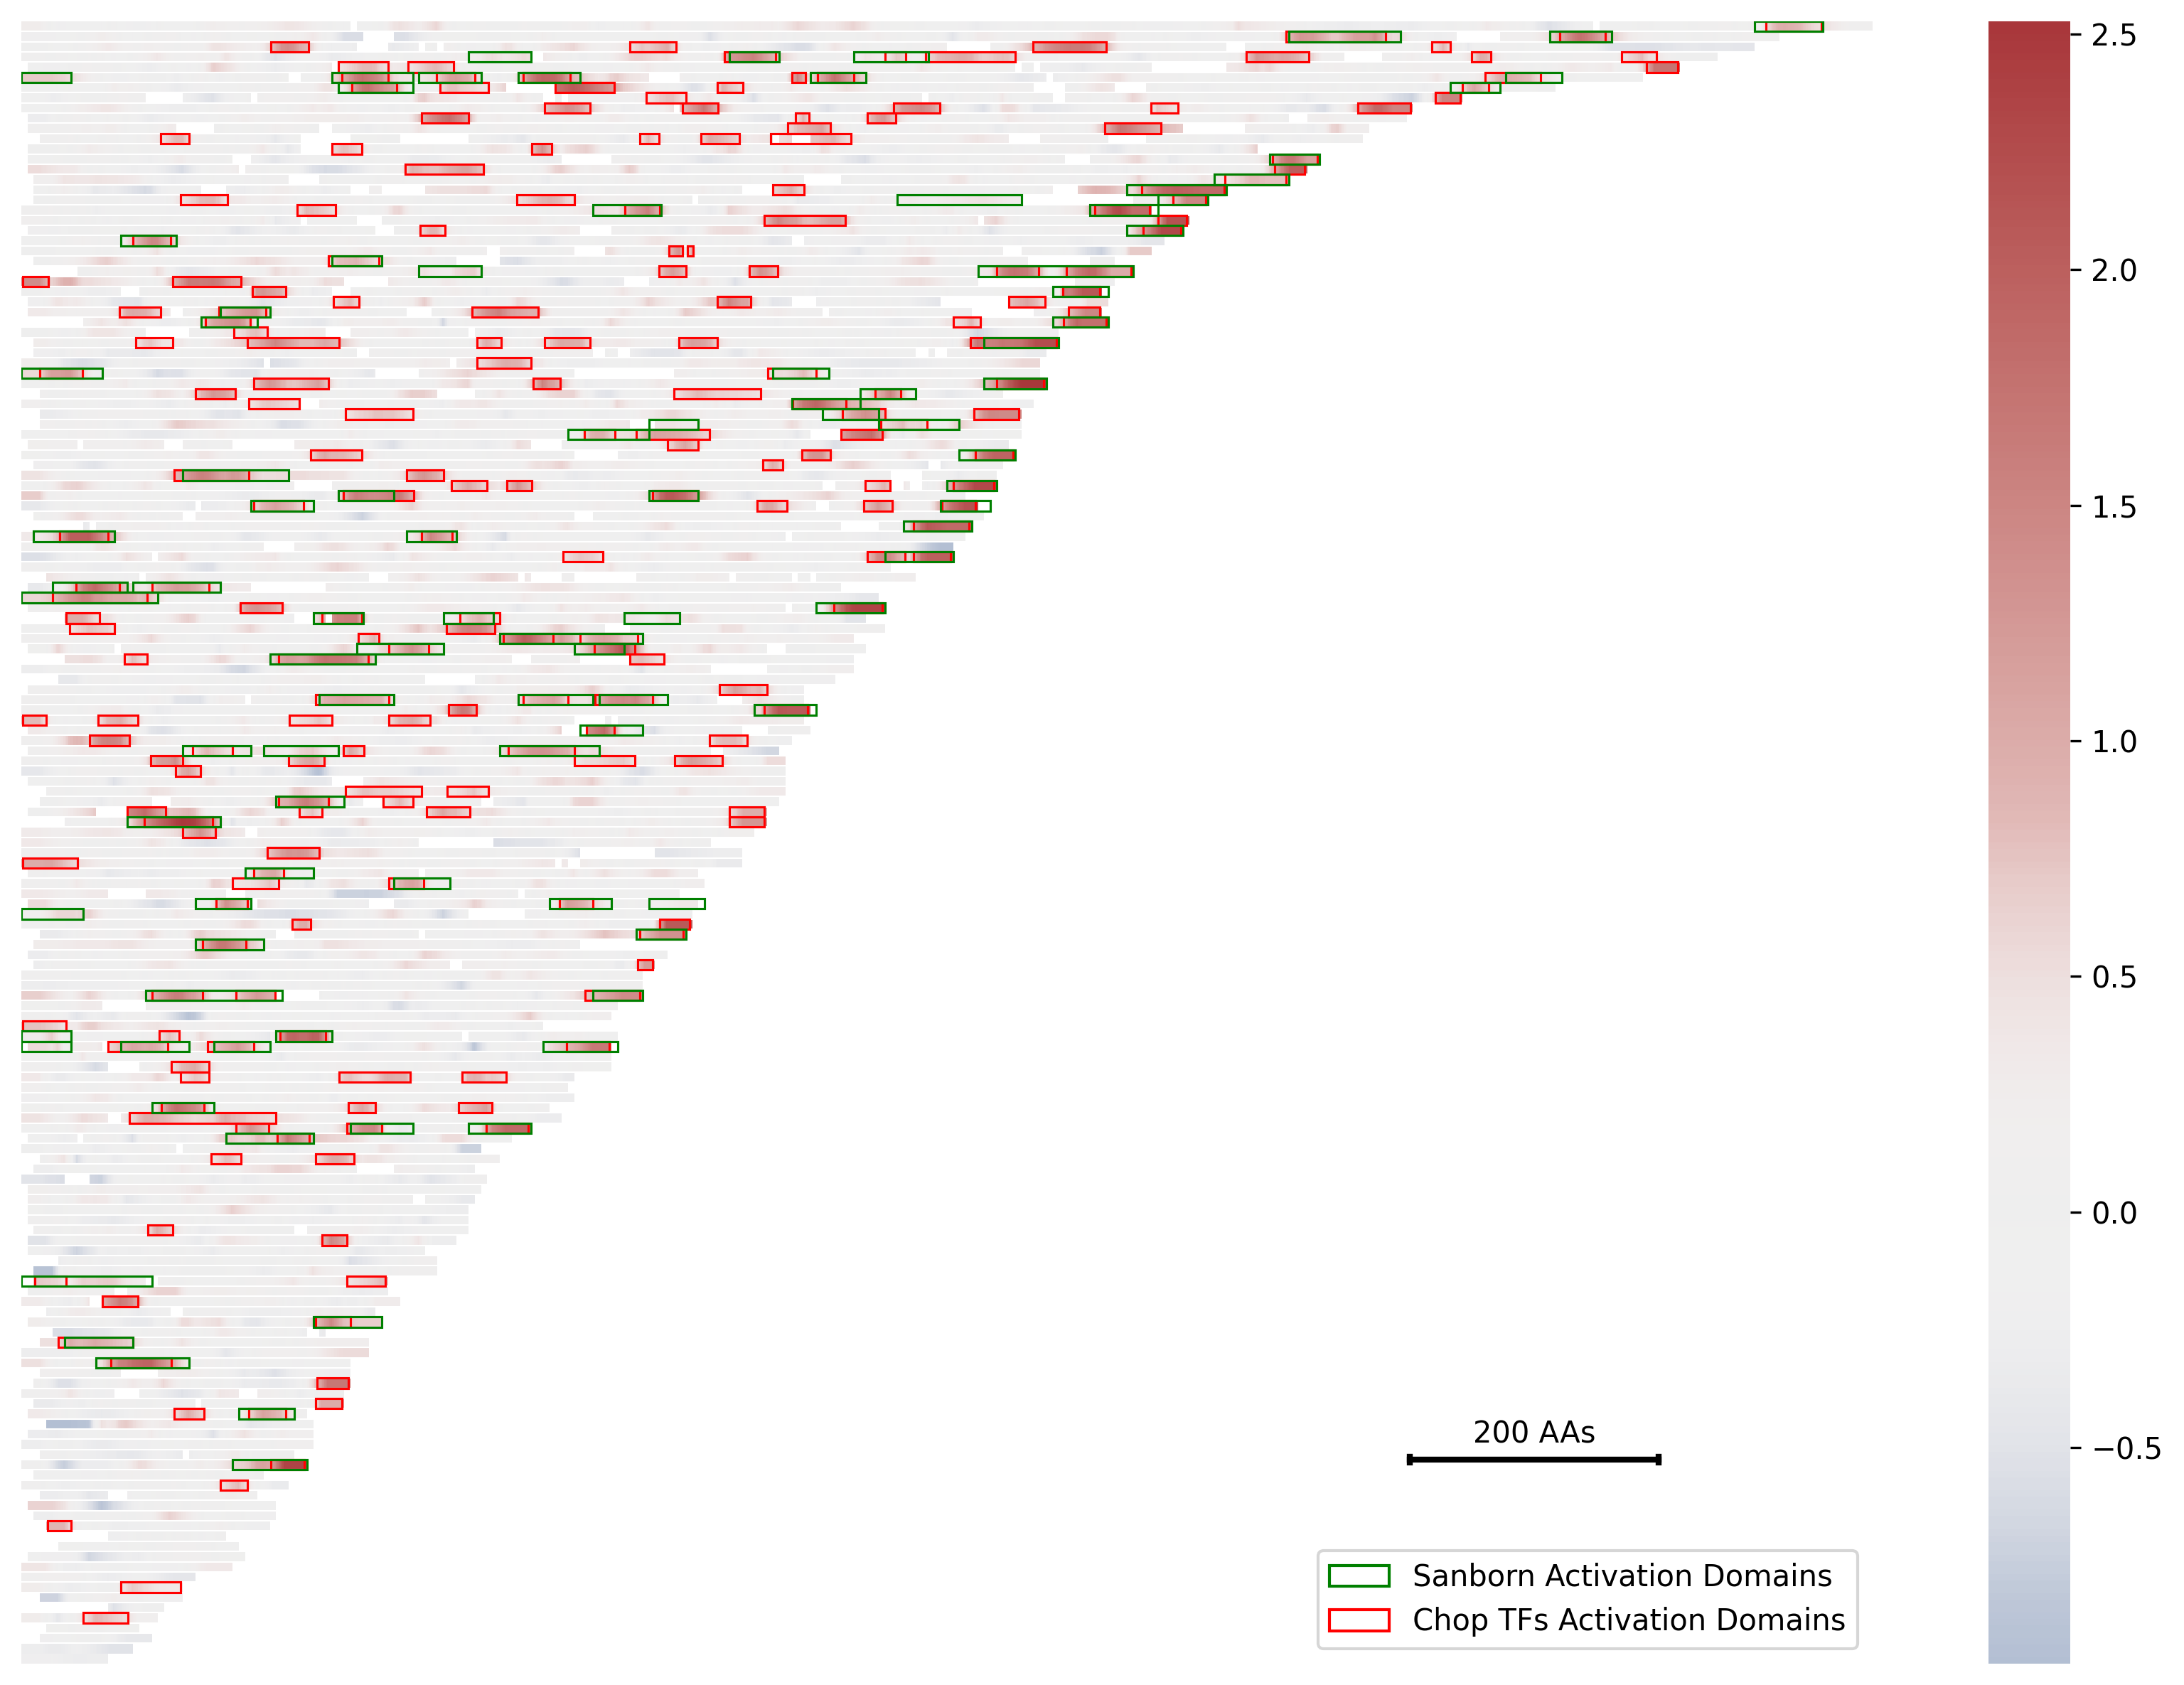

In [92]:
plot_heatmap(mat, 
             should_add_boxes=True, 
             ADs = stricter_ads_merged, 
            RDs = None,
            save_path = "../../output/paper_figs/X_ChopTFs_Sanborn_heatmap")

# Volcano Plot

In [74]:
df = pd.read_parquet("../../output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities_bootstrapped_error_all_bootstraps.parquet")
df

,ADseq,time,mean,ci_low,ci_hi,boot_samples
0,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0.366271,-0.011219,0.707915,"[0.28966835, nan, 0.13922447, 0.14990397, 0.40..."
1,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,5,0.469570,0.204091,0.840484,"[0.3001379, 0.30960295, 0.48555014, 0.6939061,..."
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,10,0.126289,-0.162042,0.268215,"[0.18833905, 0.096717775, 0.100743815, 0.31507..."
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,15,0.189880,-0.123463,0.409278,"[-0.15126646, nan, 0.02642873, 0.28805247, 0.3..."
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,20,0.063215,-0.080826,0.187016,"[0.15320866, -0.052013915, 0.05973429, 0.11016..."
...,...,...,...,...,...,...
118808,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,20,0.509707,0.421654,0.581735,"[0.57404816, 0.4747939, 0.5203182, 0.50324464,..."
118809,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,30,0.647316,0.497563,0.797139,"[0.6301339, 0.70829654, 0.7443419, 0.702255, 0..."
118810,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,40,0.752322,0.607649,0.938344,"[0.72363544, 0.75438833, 0.75584716, 0.8124503..."
118811,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,50,0.674640,0.585810,0.770303,"[0.6820687, 0.68139046, 0.7125865, 0.7560277, ..."


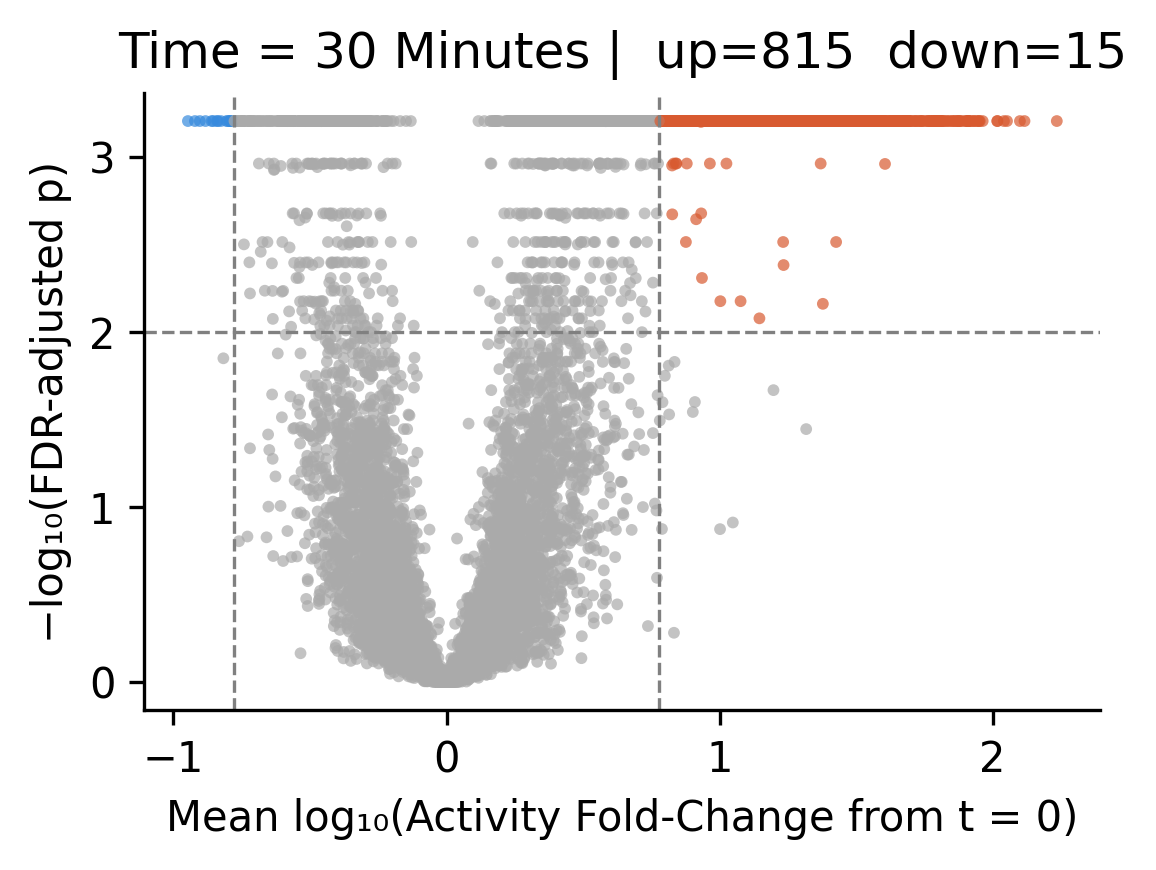

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── p-value from bootstrap difference distribution ───────────────────────────
def empirical_pval(boot_diff):
    samples = np.array(boot_diff, dtype=float)
    samples = samples[~np.isnan(samples)]
    if len(samples) == 0:
        return np.nan
    p = min(np.mean(samples <= 0), np.mean(samples >= 0))
    return np.clip(2 * p, 1 / len(samples), 1.0)

# ── join t=0 onto every other timepoint ─────────────────────────────────────
t0 = (
    df[df["time"] == 0]
    .set_index("ADseq")[["mean", "boot_samples"]]
    .rename(columns={"mean": "mean_t0", "boot_samples": "boot_t0"})
)

df_diff = df[df["time"] != 0].join(t0, on="ADseq")

# ── effect size: mean difference ─────────────────────────────────────────────
df_diff["mean_diff"] = df_diff["mean"] - df_diff["mean_t0"]

# ── bootstrap difference distribution (element-wise, NaN-aware) ──────────────
def safe_diff(a, b):
    # guard against scalar NaN from failed join
    if np.isscalar(a) or np.isscalar(b):
        return np.array([], dtype=float)
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    mask = ~(np.isnan(a) | np.isnan(b))
    return a[mask] - b[mask]

df_diff["boot_diff"] = df_diff.apply(
    lambda row: safe_diff(row["boot_samples"], row["boot_t0"]), axis=1
)

# ── p-values ─────────────────────────────────────────────────────────────────
df_diff["pval"]      = df_diff["boot_diff"].apply(empirical_pval)
df_diff["neglog10p"] = -np.log10(df_diff["pval"].clip(lower=1e-300))

# ── volcano plot ──────────────────────────────────────────────────────────────
from statsmodels.stats.multitest import multipletests

def add_fdr(df_diff, pval_thresh=0.01, diff_thresh=0.7):
    results = []
    
    for t, sub in df_diff.groupby("time"):
        sub = sub.copy()
        sub = sub.dropna(subset=["pval", "mean_diff"])
        
        # BH correction per timepoint
        reject, pval_fdr, _, _ = multipletests(sub["pval"], alpha=pval_thresh, method="fdr_bh")
        sub["pval_fdr"] = pval_fdr
        sub["reject"]   = reject
        results.append(sub)
    
    return pd.concat(results)

df_diff = add_fdr(df_diff)

# then in plot_volcano, swap pval for pval_fdr
def plot_volcano(df, timepoint, pval_thresh=0.01, diff_thresh=0.778, jitter=0.05, seed=42):
    sub = df[df["time"] == timepoint].copy()
    sub = sub.dropna(subset=["mean_diff", "neglog10p"])
    sub = sub[np.isfinite(sub["mean_diff"]) & np.isfinite(sub["neglog10p"])]

    up   = (sub["pval_fdr"] < pval_thresh) & (sub["mean_diff"] >  diff_thresh)
    down = (sub["pval_fdr"] < pval_thresh) & (sub["mean_diff"] < -diff_thresh)
    ns   = ~(up | down)

    colors = np.where(up, "#D85A30", np.where(down, "#378ADD", "#AAAAAA"))

    rng    = np.random.default_rng(seed)
    y_plot = -np.log10(sub["pval_fdr"].clip(lower=1e-300))
    y_plot = y_plot # + rng.uniform(-jitter, jitter, size=len(sub))

    fig, ax = plt.subplots(figsize=(4,3), dpi = 300)
    ax.scatter(sub["mean_diff"], y_plot, c=colors, s=8, alpha=0.7, linewidths=0)

    ax.axhline(-np.log10(pval_thresh), color="gray", lw=0.8, ls="--")
    ax.axvline( diff_thresh,           color="gray", lw=0.8, ls="--")
    ax.axvline(-diff_thresh,           color="gray", lw=0.8, ls="--")

    ax.set_xlabel("Mean log₁₀(Activity Fold-Change from t = 0)")
    ax.set_ylabel("−log₁₀(FDR-adjusted p)")
    ax.set_title(f"Time = {timepoint} Minutes |  up={up.sum()}  down={down.sum()}")

    sns.despine()
    plt.tight_layout()
    return fig, ax

fig, ax = plot_volcano(df_diff, 30)
fig.savefig('../../output/paper_figs/X_ChopTFs_t30_volcano.png', dpi=300, bbox_inches='tight')
fig.savefig('../../output/paper_figs/X_ChopTFs_t30_volcano.pdf', dpi=300, bbox_inches='tight')